In [1]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

from scipy.interpolate import interp1d
import scipy
print(scipy.__version__)

import resin_spectral_analysis.data as data
from resin_spectral_analysis.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from resin_spectral_analysis.irradiance import Irradiance
from resin_spectral_analysis.utilities import ArrayParams, find_index_of_nearest, find_index_of_max, shift, shift_peak_wavelength
from resin_spectral_analysis.normalizeddose import NormalizedDose
from resin_spectral_analysis.sourcespectrum import SourceSpectrum

1.8.1


# Common variables

In [15]:
wavelengths = np.linspace(*ArrayParams(300, 440, 281))

z_array_params = ArrayParams(0, 100, 201)

wavelength_array_params=ArrayParams(300, 440, 281)

save_plot_figures = False

# Absorbers

## Create resins

In [3]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
avobenzone = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    2.0
)

nps = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)

irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

resin = Resin(monomers=pegda, absorbers=[avobenzone,nps], photoinitiators=irgacure819)
resin_nps = Resin(monomers=pegda, absorbers=nps)
resin_avo = Resin(monomers=pegda, absorbers=avobenzone)


## Plot absorber resin_spectral_analysis

(0.0, 0.7)

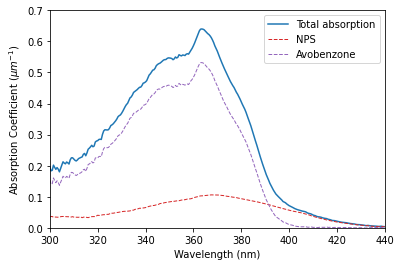

In [4]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C3', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper right')
ax.set_xlim(300,440)
ax.set_ylim(0, 0.7)
# ax.grid()


# Sources

In [5]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a970>,
 'Asiga_405nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a640>,
 'HR1_385nm_100um_fiber-2016-12-14': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a4f0>,
 'HR2_385nm_2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a490>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a430>,
 'HR3.2_365nm_no_filter-2019-12-31': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a730>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a790>,
 'HR3.3_365nm_no_filter-2020-03-23': <resin_spectral_analysis.sourcespectrum.SourceSpectrum at 0x7f9a4820a7f0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <resin

## 365 nm with and without short pass filter

In [6]:
source_365nm = data.sources['HR3.2_365nm_no_filter-2019-12-31']
source_365nm_shortpass = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']


## Construct a bandpass filter

### Approach 

Use Asahi short pass filter data as the right edge of a bandpass filter. Reflect it to create the left edge of the filter. Specify center wavelength and wavelength width of top of bandbass filter to create the full filter.

### Read Asahi transmission data

In [7]:
asahi_measured_data = np.genfromtxt('370nm shortpass filter_original.csv', delimiter=',', skip_header=2)

# Convert from percent to fractional transmission
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/100.


### Figure out which data points to use

71
78


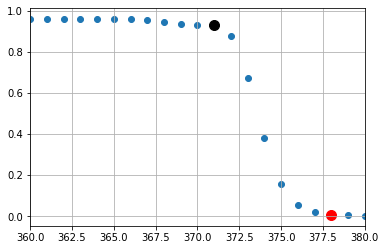

In [8]:
index_temp = find_index_of_nearest(asahi_measured_data[:,0], 371)
print(index_temp)
index_temp2 = find_index_of_nearest(asahi_measured_data[:,0], 378)
print(index_temp2)

fig, ax = plt.subplots()
ax.scatter(asahi_measured_data[:,0], asahi_measured_data[:,1])
ax.scatter(asahi_measured_data[index_temp,0], asahi_measured_data[index_temp,1], c='k', s=100)
ax.scatter(asahi_measured_data[index_temp2,0], asahi_measured_data[index_temp2,1], c='r', s=100)
ax.set_xlim(360,380)
ax.grid()

Use data points between and including 371 nm and 378 nm (8 data points). Normalize to the transmission value at 371 nm.

In [9]:
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/np.max(asahi_measured_data[index_temp, 1])

print(asahi_measured_data[index_temp:index_temp2+1,0])
print(asahi_measured_data[index_temp:index_temp2+1,1])

[371. 372. 373. 374. 375. 376. 377. 378.]
[1.         0.93890508 0.72161036 0.40772658 0.16543623 0.05495517
 0.01830751 0.00675427]


### Create asahi interpolation function for short pass filter edge

In [10]:
temp_wavelengths = asahi_measured_data[index_temp:index_temp2+1,0].copy()
temp_transmission = asahi_measured_data[index_temp:index_temp2+1,1]

delta_wavelength = np.linspace(0, 
                               temp_wavelengths[-1] - temp_wavelengths[0],
                               len(temp_wavelengths)
                              )
print(temp_wavelengths)
print(delta_wavelength)
print(temp_transmission)

asahi_interp1d = interp1d(delta_wavelength, 
                          temp_transmission,
                          kind='cubic',
                          fill_value=(1,0), 
                          bounds_error=False
                         )


[371. 372. 373. 374. 375. 376. 377. 378.]
[0. 1. 2. 3. 4. 5. 6. 7.]
[1.         0.93890508 0.72161036 0.40772658 0.16543623 0.05495517
 0.01830751 0.00675427]


In [11]:
def bandpass_filter_transmission(wavelengths, center_wavelength, delta_wavelength):
    result = np.zeros(len(wavelengths))
    d2 = delta_wavelength / 2.0
    for i, w in enumerate(wavelengths):
        if -d2 <= w - center_wavelength <= d2:
            result[i] = 1.0
        elif w - center_wavelength > d2:
            result[i] = asahi_interp1d(w - center_wavelength - d2)
        else:
            result[i] = asahi_interp1d(center_wavelength - w - d2)
    return result
            
w_temp = np.linspace(350, 390, 41)
print(w_temp)

bandpass_filter_transmission(w_temp, 370, 10)

[350. 351. 352. 353. 354. 355. 356. 357. 358. 359. 360. 361. 362. 363.
 364. 365. 366. 367. 368. 369. 370. 371. 372. 373. 374. 375. 376. 377.
 378. 379. 380. 381. 382. 383. 384. 385. 386. 387. 388. 389. 390.]


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00675427, 0.01830751,
       0.05495517, 0.16543623, 0.40772658, 0.72161036, 0.93890508,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.93890508, 0.72161036, 0.40772658, 0.16543623,
       0.05495517, 0.01830751, 0.00675427, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

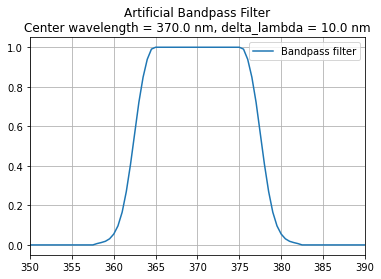

In [12]:
center_wavelength = 370.
delta_wavelength = 10.

fig, ax = plt.subplots()
ax.plot(wavelengths, 
        bandpass_filter_transmission(wavelengths, center_wavelength, delta_wavelength), 
        label='Bandpass filter'
       )
ax.set_xlim(350,390)
ax.legend()
ax.set_title(f"Artificial Bandpass Filter\nCenter wavelength = {center_wavelength} nm, delta_lambda = {delta_wavelength} nm")
ax.grid()

## 385 nm with and without bandpass filter

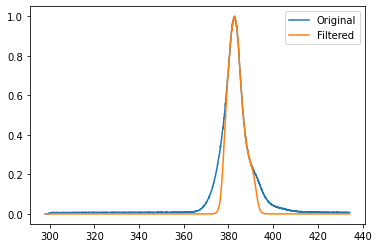

In [13]:
source_385nm = data.sources['HR2_385nm_2020-03-23']
source_385nm_filtered = copy.deepcopy(source_385nm)
source_385nm_filtered.power = source_385nm_filtered.power * \
        bandpass_filter_transmission(source_385nm_filtered.wavelength, 385, 10)
source_385nm_filtered.name = source_385nm_filtered.name + '_filtered'


fig, ax = plt.subplots()
ax.plot(source_385nm.wavelength, source_385nm.power, label='Original')
ax.plot(source_385nm_filtered.wavelength, source_385nm_filtered.power, label='Filtered')
ax.legend();

## 395 nm with and without bandpass filter

Make 395 nm source by shifting 385 nm source to 395 nm.

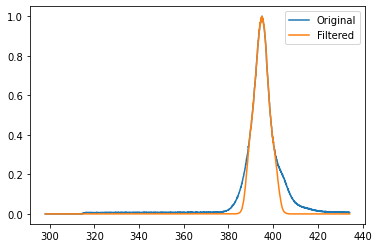

In [14]:
source_395nm = copy.deepcopy(source_385nm)
source_395nm.power = shift_peak_wavelength(395, source_395nm.wavelength, source_395nm.power)
source_395nm.name = source_395nm.name + '_shift_to_395nm'


source_395nm_filtered = copy.deepcopy(source_395nm)
source_395nm_filtered.power = source_395nm_filtered.power * \
        bandpass_filter_transmission(source_395nm_filtered.wavelength, 395, 10)
source_395nm_filtered.name = source_395nm_filtered.name + '_filtered'

    
fig, ax = plt.subplots()
ax.plot(source_395nm.wavelength, source_395nm.power, label='Original')
ax.plot(source_395nm_filtered.wavelength, source_395nm_filtered.power, label='Filtered')
ax.legend();

# h_a and spectrum comparisons

## 365 nm and 385 nm

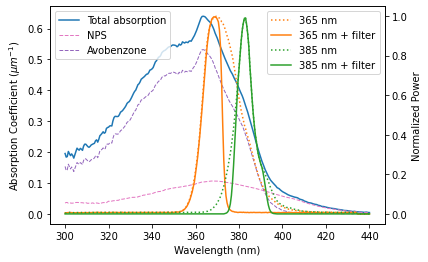

In [16]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C6', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_365nm.calc_power(wavelengths), c='C1', ls=':', label='365 nm')
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C1', label='365 nm + filter')
ax2.plot(wavelengths, source_385nm.calc_power(wavelengths), c='C2', ls=':', label='385 nm')
ax2.plot(wavelengths, source_385nm_filtered.calc_power(wavelengths), c='C2', label='385 nm + filter')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');

if save_plot_figures: plt.savefig('365nm_385nm_sources.png')


### 365 nm h_a

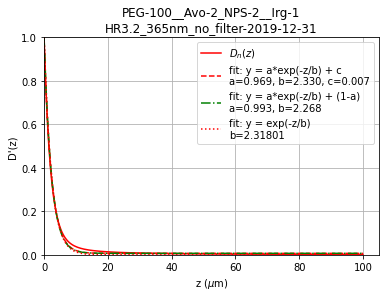

In [17]:
irradiance_365 = Irradiance(source=source_365nm, resin=resin, wavelength_array_params=ArrayParams(300, 440, 601))
norm_dose_365 = NormalizedDose(irradiance=irradiance_365, z_array_params=z_array_params)

norm_dose_365.plot(title=(norm_dose_365.irradiance.resin.name + "\n" + norm_dose_365.irradiance.source.name));

if save_plot_figures: plt.savefig('NormDose_365nm_source.png')


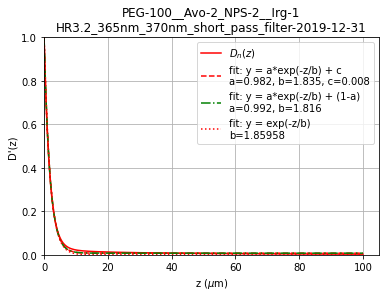

In [18]:
irradiance_365_filtered = Irradiance(source=source_365nm_shortpass, 
                                     resin=resin, 
                                     wavelength_array_params=ArrayParams(300, 440, 601)
                                    )
norm_dose_365_filtered = NormalizedDose(irradiance=irradiance_365_filtered, z_array_params=z_array_params)

norm_dose_365_filtered.plot(
    title=(norm_dose_365_filtered.irradiance.resin.name + "\n" + norm_dose_365_filtered.irradiance.source.name)
);

if save_plot_figures: plt.savefig('NormDose_365nm_filtered_source.png')


### 385 nm h_a

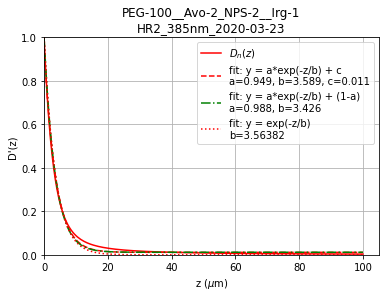

In [19]:
irradiance_385 = Irradiance(source=source_385nm, resin=resin, wavelength_array_params=ArrayParams(300, 440, 601))
norm_dose_385 = NormalizedDose(irradiance=irradiance_385, z_array_params=z_array_params)

norm_dose_385.plot(title=(norm_dose_385.irradiance.resin.name + "\n" + norm_dose_385.irradiance.source.name));

if save_plot_figures: plt.savefig('NormDose_365nm_source.png')


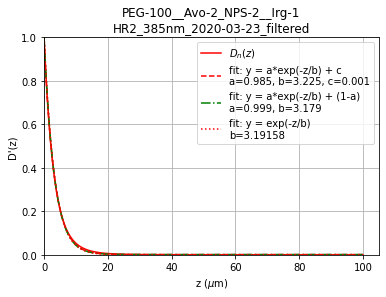

In [20]:
irradiance_385_filtered = Irradiance(source=source_385nm_filtered, 
                                     resin=resin, 
                                     wavelength_array_params=ArrayParams(300, 440, 601)
                                    )
norm_dose_385_filtered = NormalizedDose(irradiance=irradiance_385_filtered, z_array_params=z_array_params)

norm_dose_385_filtered.plot(
    title=(norm_dose_385_filtered.irradiance.resin.name + "\n" + norm_dose_385_filtered.irradiance.source.name)
);

if save_plot_figures: plt.savefig('NormDose_385nm_filtered_source.png')


## 365 nm and 395 nm

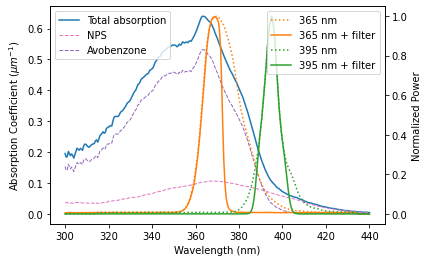

In [21]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), label='Total absorption')
ax.plot(wavelengths, resin_nps.calc_absorption_coef_inv_um(wavelengths), c='C6', lw=1, ls='--', label='NPS')
ax.plot(wavelengths, resin_avo.calc_absorption_coef_inv_um(wavelengths), c='C4', lw=1, ls='--', label='Avobenzone')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_365nm.calc_power(wavelengths), c='C1', ls=':', label='365 nm')
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C1', label='365 nm + filter')
ax2.plot(wavelengths, source_395nm.calc_power(wavelengths), c='C2', ls=':', label='395 nm')
ax2.plot(wavelengths, source_395nm_filtered.calc_power(wavelengths), c='C2', label='395 nm + filter')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');

if save_plot_figures: plt.savefig('365nm_395nm_sources.png')


### 395 nm h_a

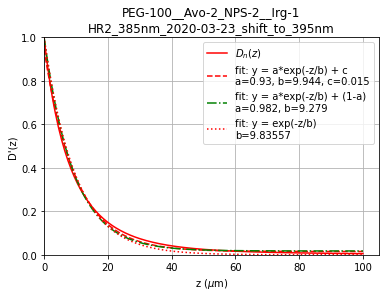

In [22]:
irradiance_395 = Irradiance(source=source_395nm, resin=resin, wavelength_array_params=ArrayParams(300, 440, 601))
norm_dose_395 = NormalizedDose(irradiance=irradiance_395, z_array_params=z_array_params)

norm_dose_395.plot(title=(norm_dose_395.irradiance.resin.name + "\n" + norm_dose_395.irradiance.source.name));

if save_plot_figures: plt.savefig('NormDose_395nm_source.png')


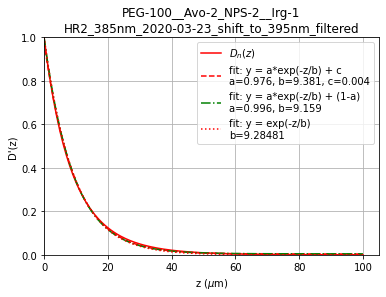

In [23]:
irradiance_395_filtered = Irradiance(source=source_395nm_filtered, 
                                     resin=resin, 
                                     wavelength_array_params=ArrayParams(300, 440, 601)
                                    )
norm_dose_395_filtered = NormalizedDose(irradiance=irradiance_395_filtered, z_array_params=z_array_params)

norm_dose_395_filtered.plot(
    title=(norm_dose_395_filtered.irradiance.resin.name + "\n" + norm_dose_395_filtered.irradiance.source.name)
);

if save_plot_figures: plt.savefig('NormDose_395nm_filtered_source.png')
